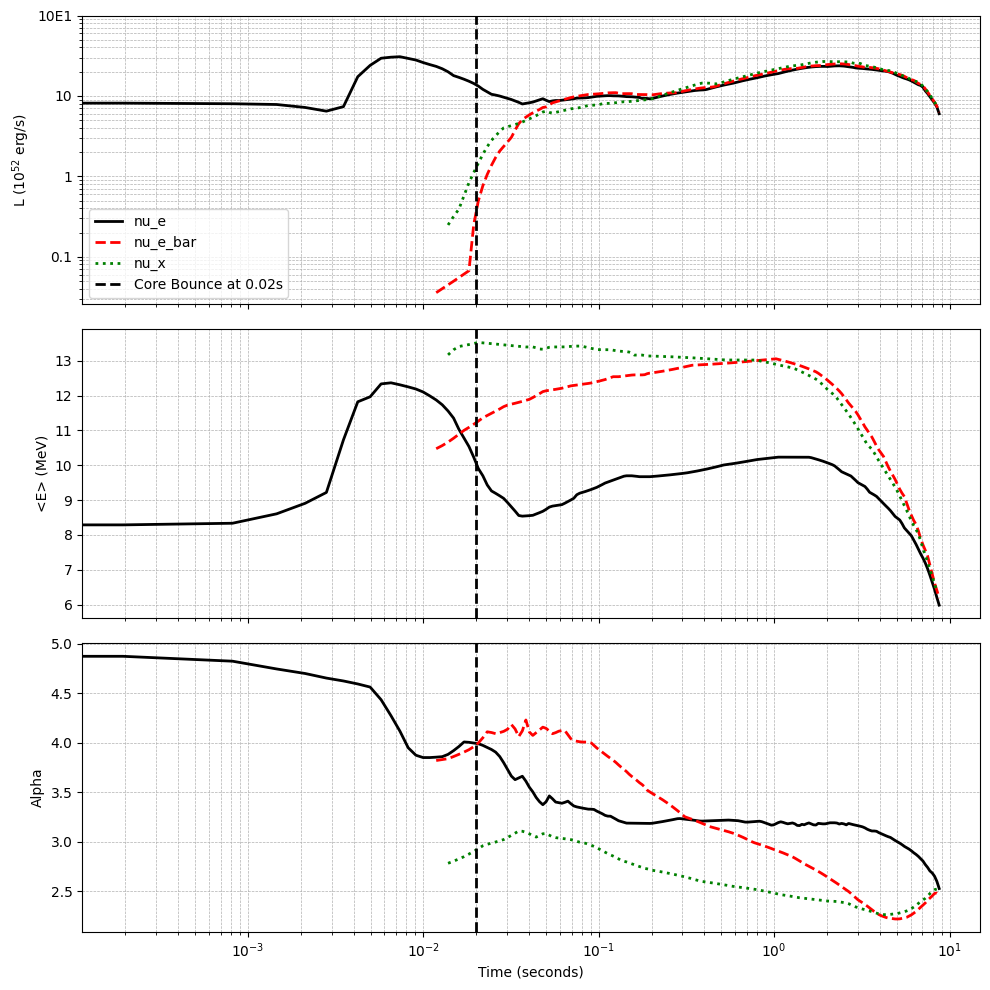

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# Define directories
base_directory = "/Users/jacob/Downloads/garching"
data_directory = os.path.join(base_directory, "garching_fluxes_log")

# Define file paths
file_pattern = os.path.join(data_directory, "pinched_*.dat")  
info_key_file = os.path.join(base_directory, "garching_pinched_info_key.dat")
info_file = os.path.join(base_directory, "garching_pinched_info.dat")

# Load data
info_key_data = np.loadtxt(info_key_file)
info_data = np.loadtxt(info_file)

# Extract relevant columns for alpha, energy, and luminosity
id_to_time = {int(row[0]): row[1] for row in info_key_data}
id_to_alpha = {int(row[0]): (row[1], row[2], row[3]) for row in info_data}  # Alpha values (nu_e, nu_e_bar, nu_x)
id_to_energy = {int(row[0]): (row[4], row[5], row[6]) for row in info_data}  # Energy values (nu_e, nu_e_bar, nu_x)
id_to_luminosity = {int(row[0]): (row[7], row[8], row[9]) for row in info_data}  # Luminosity values (nu_e, nu_e_bar, nu_x)

# Get sorted list of pinched files
file_list = sorted(glob.glob(file_pattern), key=lambda x: int(x.split("_")[-1].split(".")[0]))

# Store data
time_values = []
alpha_values, energy_values, luminosity_values = {}, {}, {}
for species in ["nu_e", "nu_e_bar", "nu_x"]:
    alpha_values[species] = []
    energy_values[species] = []
    luminosity_values[species] = []

# Process files
for file in file_list:
    file_id = int(file.split("_")[-1].split(".")[0])
    if file_id in id_to_time:
        time_bin = id_to_time[file_id]
        #print(time_bin)
        alpha_vals = id_to_alpha.get(file_id, (np.nan, np.nan, np.nan))
        energy_vals = id_to_energy.get(file_id, (np.nan, np.nan, np.nan))
        luminosity_vals = id_to_luminosity.get(file_id, (np.nan, np.nan, np.nan))

        # Append valid data
        time_values.append(time_bin)
        for i, species in enumerate(["nu_e", "nu_e_bar", "nu_x"]):
            alpha_values[species].append(alpha_vals[i] if alpha_vals[i] != 0 else np.nan)
            energy_values[species].append(energy_vals[i] if energy_vals[i] != 0 else np.nan)
            luminosity_values[species].append(luminosity_vals[i] if luminosity_vals[i] != 0 else np.nan)

# Convert to arrays
time_values = np.array(time_values)

for species in species_list:
    alpha_values[species] = np.array(alpha_values[species], dtype=float)
    energy_values[species] = np.array(energy_values[species], dtype=float)
    luminosity_values[species] = np.array(luminosity_values[species], dtype=float) / 10e48  # Corrected


#time_shift = 0.02
#time_values = time_values + time_shift


# Define species styles
species_list = ["nu_e", "nu_e_bar", "nu_x"]
colors = {"nu_e": "black", "nu_e_bar": "red", "nu_x": "green"}
linestyles = {"nu_e": "-", "nu_e_bar": "--", "nu_x": ":"}

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Function for plotting
def plot_data(ax, y_values, ylabel, log_y=False):
    for species in species_list:
        valid_mask = ~np.isnan(y_values[species])  # Ignore NaNs
        ax.plot(time_values[valid_mask], np.array(y_values[species])[valid_mask],
                linestyle=linestyles[species], color=colors[species], linewidth=2, label=species)
    ax.set_yscale('log' if log_y else 'linear')
    ax.axvline(x=0.02, color='k', linestyle='--', linewidth=2, label="Core Bounce at 0.02s")  # Vertical line at 0.02s
    ax.set_ylabel(ylabel)
    #plt.xlim(left = 10E-3)
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    

# Plot Luminosity
plot_data(axes[0], luminosity_values, r"L ($10^{52}$ erg/s)", log_y=True)
axes[0].set_yticks([0.1, 1, 10,10E1]) 
axes[0].set_yticklabels(["0.1", "1", "10", "10E1"]) 

# Plot Energy
plot_data(axes[1], energy_values, r"<E> (MeV)")

# Plot Alpha
plot_data(axes[2], alpha_values, r"Alpha")

# Set log scale for time
axes[-1].set_xscale('log')
axes[-1].set_xlabel("Time (seconds)")

# Add legend
axes[0].legend(loc="best")

plt.tight_layout()
plt.show()